# Práctica guiada: aprendizaje no supervisado con Wine Clustering

En esta práctica vas a aplicar técnicas de **aprendizaje no supervisado** al dataset `wine-clustering.csv`.

## Objetivos
- Explorar un conjunto de datos sin etiquetas.
- Preparar los datos correctamente.
- Aplicar **K-Means** con distintos valores de `k`.
- Utilizar el **método del codo** y el **silhouette score**.
- Interpretar los clusters obtenidos.

> Completa las celdas y responde a las cuestiones planteadas.


## 1. Carga del dataset

Carga el archivo CSV en un DataFrame llamado `df` y muestra las primeras filas.


In [1]:
import pandas as pd

df = pd.read_csv("wine-clustering.csv")

df.head()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


## 2. Primer análisis del dataset

Obtén:
- número de filas y columnas;
- tipos de datos;
- estadísticos descriptivos.

### Cuestión
¿Todas las variables son numéricas? ¿Hay diferencias importantes de escala entre unas columnas y otras?
Si, todas son numericas.
Si, hay diferencias importantes en cuanto a la escala, hay datos sobre 1000 y otro sobre 2-3, hay que normalizarlo si o si, es un gran diferencia.


In [2]:
# Escribe aquí tu código

df.shape

(178, 13)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Alcohol               178 non-null    float64
 1   Malic_Acid            178 non-null    float64
 2   Ash                   178 non-null    float64
 3   Ash_Alcanity          178 non-null    float64
 4   Magnesium             178 non-null    int64  
 5   Total_Phenols         178 non-null    float64
 6   Flavanoids            178 non-null    float64
 7   Nonflavanoid_Phenols  178 non-null    float64
 8   Proanthocyanins       178 non-null    float64
 9   Color_Intensity       178 non-null    float64
 10  Hue                   178 non-null    float64
 11  OD280                 178 non-null    float64
 12  Proline               178 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 18.2 KB


## 3. Preprocesamiento

Aplica un escalado con `StandardScaler`.

### Cuestión
¿Por qué es importante escalar los datos antes de aplicar K-Means?
Porque es un algoritmo que se basa en distancias, en unir puntos en base a sus centroides, si no escalamos, podemos incorporar datos con mucha diferencia entre unos y otros, lo que modificaría para mal, el analisis y la visualización de la misma.


In [5]:
from sklearn.preprocessing import StandardScaler

# Crea una variable X con las columnas del dataset
# Después escala los datos y guarda el resultado en X_scaled

X = df

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 4. Prueba distintos valores de k

Calcula la **inercia** y el **silhouette score** para valores de `k` entre 2 y 10.


In [14]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inercias = []
silhouettes = []
valores_k = range(2, 11)

# Completa el bucle
for k in valores_k:
    # 1. Instanciar el modelo
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    
    # 2. Ajustar el modelo y predecir las etiquetas
    labels = kmeans.fit_predict(X_scaled) 
    
    # 3. Guardar la inercia (sum of squared distances)
    inercias.append(kmeans.inertia_)
    
    # 4. Calcular y guardar el coeficiente de silueta
    score = silhouette_score(X_scaled, labels)
    silhouettes.append(score)


## 5. Representa el método del codo

Haz una gráfica de `k` frente a `inercia`.

### Cuestión
¿En qué valor de `k` parece producirse el “codo”?
Parece producirse en el 3.

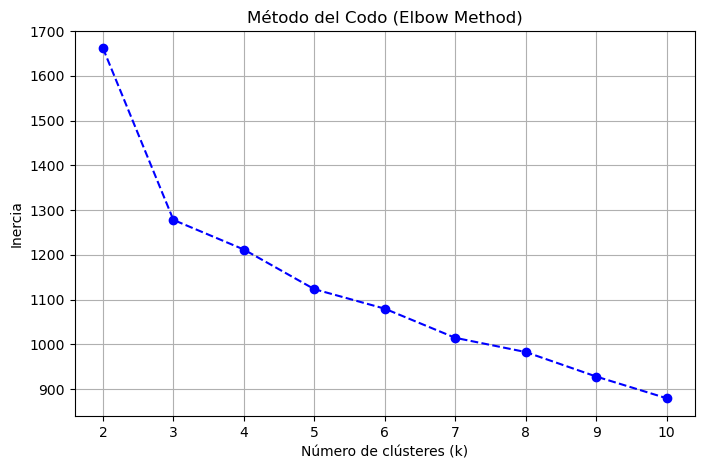

In [15]:
import matplotlib.pyplot as plt

# Escribe aquí tu código

plt.figure(figsize=(8, 5))
plt.plot(valores_k, inercias, marker='o', linestyle='--', color='b')
plt.title('Método del Codo (Elbow Method)')
plt.xlabel('Número de clústeres (k)')
plt.ylabel('Inercia')
plt.xticks(valores_k)
plt.grid(True)
plt.show()

## 6. Representa el silhouette score

Haz una gráfica de `k` frente a `silhouette`.

### Cuestión
¿Qué valor de `k` obtiene el mejor resultado?
El mejor es el 3.

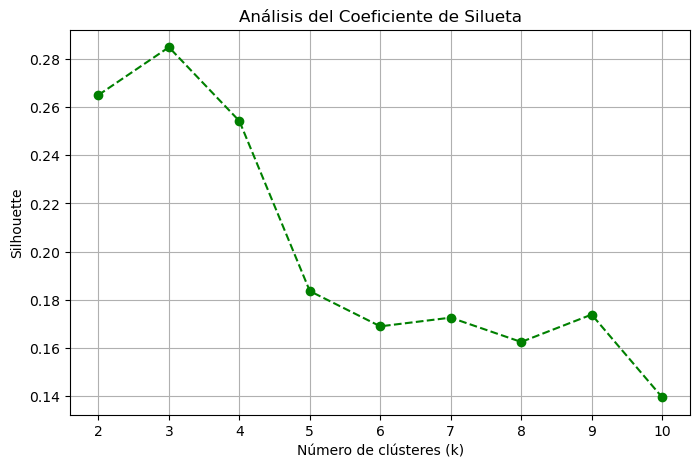

In [16]:
# Escribe aquí tu código
plt.figure(figsize=(8, 5))
plt.plot(valores_k, silhouettes, marker='o', linestyle='--', color='g')
plt.title('Análisis del Coeficiente de Silueta')
plt.xlabel('Número de clústeres (k)')
plt.ylabel('Silhouette')
plt.xticks(valores_k)
plt.grid(True)
plt.show()

## 7. Entrena el modelo final

Elige el valor de `k` que consideres más adecuado y entrena un modelo final de K-Means.

Guarda las etiquetas de cluster en una nueva columna llamada `cluster`.


In [22]:
# Escribe aquí tu código

# 1. Definimos el valor de k elegido (según la teoría del dataset Wine, es 3)
k_optimo = 3 

# 2. Instanciar y entrenar el modelo final con los datos ESCALADOS
modelo_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
clusters = modelo_final.fit_predict(X_scaled)

# 3. Guardar las etiquetas en el DataFrame original (el que no está escalado)
# para que los datos sean legibles para humanos
df['cluster'] = clusters

# Visualizar las primeras filas con la nueva columna
print(df.head())

   Alcohol  Malic_Acid   Ash  Ash_Alcanity  Magnesium  Total_Phenols  \
0    14.23        1.71  2.43          15.6        127           2.80   
1    13.20        1.78  2.14          11.2        100           2.65   
2    13.16        2.36  2.67          18.6        101           2.80   
3    14.37        1.95  2.50          16.8        113           3.85   
4    13.24        2.59  2.87          21.0        118           2.80   

   Flavanoids  Nonflavanoid_Phenols  Proanthocyanins  Color_Intensity   Hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   OD280  Proline  cluster  
0   3.92     1065        2  
1   3.40     1050        2  
2   3

## 8. Evalúa el modelo

Calcula el **silhouette score** del modelo final.

### Cuestión
¿Te parece un resultado bueno, aceptable o bajo? Razona tu respuesta.
Me parece un resultado aceptable, pero no bueno ni tampoco bajo.



In [23]:
# Escribe aquí tu código

# Calculamos el score usando los datos escalados y las etiquetas del modelo final
score_final = silhouette_score(X_scaled, clusters)

print(f"El coeficiente de silueta para k={k_optimo} es: {score_final:.4f}")

El coeficiente de silueta para k=3 es: 0.2849


## 9. Analiza el tamaño de los clusters

Cuenta cuántos registros hay en cada cluster.


In [24]:
# Escribe aquí tu código

# Contar registros por cluster
conteo_clusters = df['cluster'].value_counts().sort_index()

print("Registros por cada cluster:")
print(conteo_clusters)

Registros por cada cluster:
cluster
0    65
1    51
2    62
Name: count, dtype: int64


## 10. Interpreta los clusters

Calcula la media de cada variable por cluster.

### Cuestiones
1. ¿Qué variables parecen diferenciar más unos clusters de otros?
2. ¿Qué perfil de vino podría representar cada grupo?


In [ ]:
# Escribe aquí tu código
0

## 11. Reflexión final

Responde brevemente:

1. ¿En qué se diferencia el aprendizaje supervisado del no supervisado?
2. ¿Por qué K-Means no siempre encuentra la mejor solución posible?
3. ¿Qué papel juega el preprocesamiento en este problema?
4. ¿Qué limitaciones observas en K-Means cuando se aplica a datos reales?
